In [ ]:
#@title Default title text
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

#!ls 'drive/My Drive/local training'
import os
os.chdir('drive/My Drive/Doktora/TBC')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
file = 'TBC--Class--GVB.xyz'
df = pd.read_csv(file, header='infer')
df['CLASS'] = df['CLASS'].str.extract('(\d+)').astype(float)
df.dropna(inplace=True)
df

,X,Y,Z,ELEVATION,CLASS,INTENSITY,RETURN_NUM,RETURN_CNT,RED,GREEN,BLUE,DENSITY
0,480173.803,4556137.984,1909.852,1909.852,2.0,0,1,1,32897,29812,26471,21.367 samples / m^2
1,480174.719,4556138.684,1909.496,1909.496,2.0,11051,1,1,43948,42663,38037,18.498 samples / m^2
2,480175.005,4556138.780,1909.381,1909.381,2.0,0,1,1,33668,31868,29555,20.030 samples / m^2
3,480175.124,4556138.620,1909.512,1909.512,2.0,11051,1,1,40350,38551,36238,22.704 samples / m^2
4,480175.044,4556138.614,1909.420,1909.420,2.0,0,1,1,32640,30840,28527,22.089 samples / m^2
...,...,...,...,...,...,...,...,...,...,...,...,...
42870102,480670.032,4556158.918,1802.001,1802.001,5.0,38037,1,1,17219,23901,14649,16.791 samples / m^2
42870103,480669.999,4556158.815,1801.950,1801.950,5.0,10537,1,1,18247,24415,15420,17.042 samples / m^2
42870104,480669.983,4556158.838,1801.632,1801.632,5.0,18247,1,1,17476,23901,14392,17.092 samples / m^2
42870105,480669.971,4556158.872,1801.790,1801.790,5.0,10537,1,1,18247,24415,15420,17.080 samples / m^2


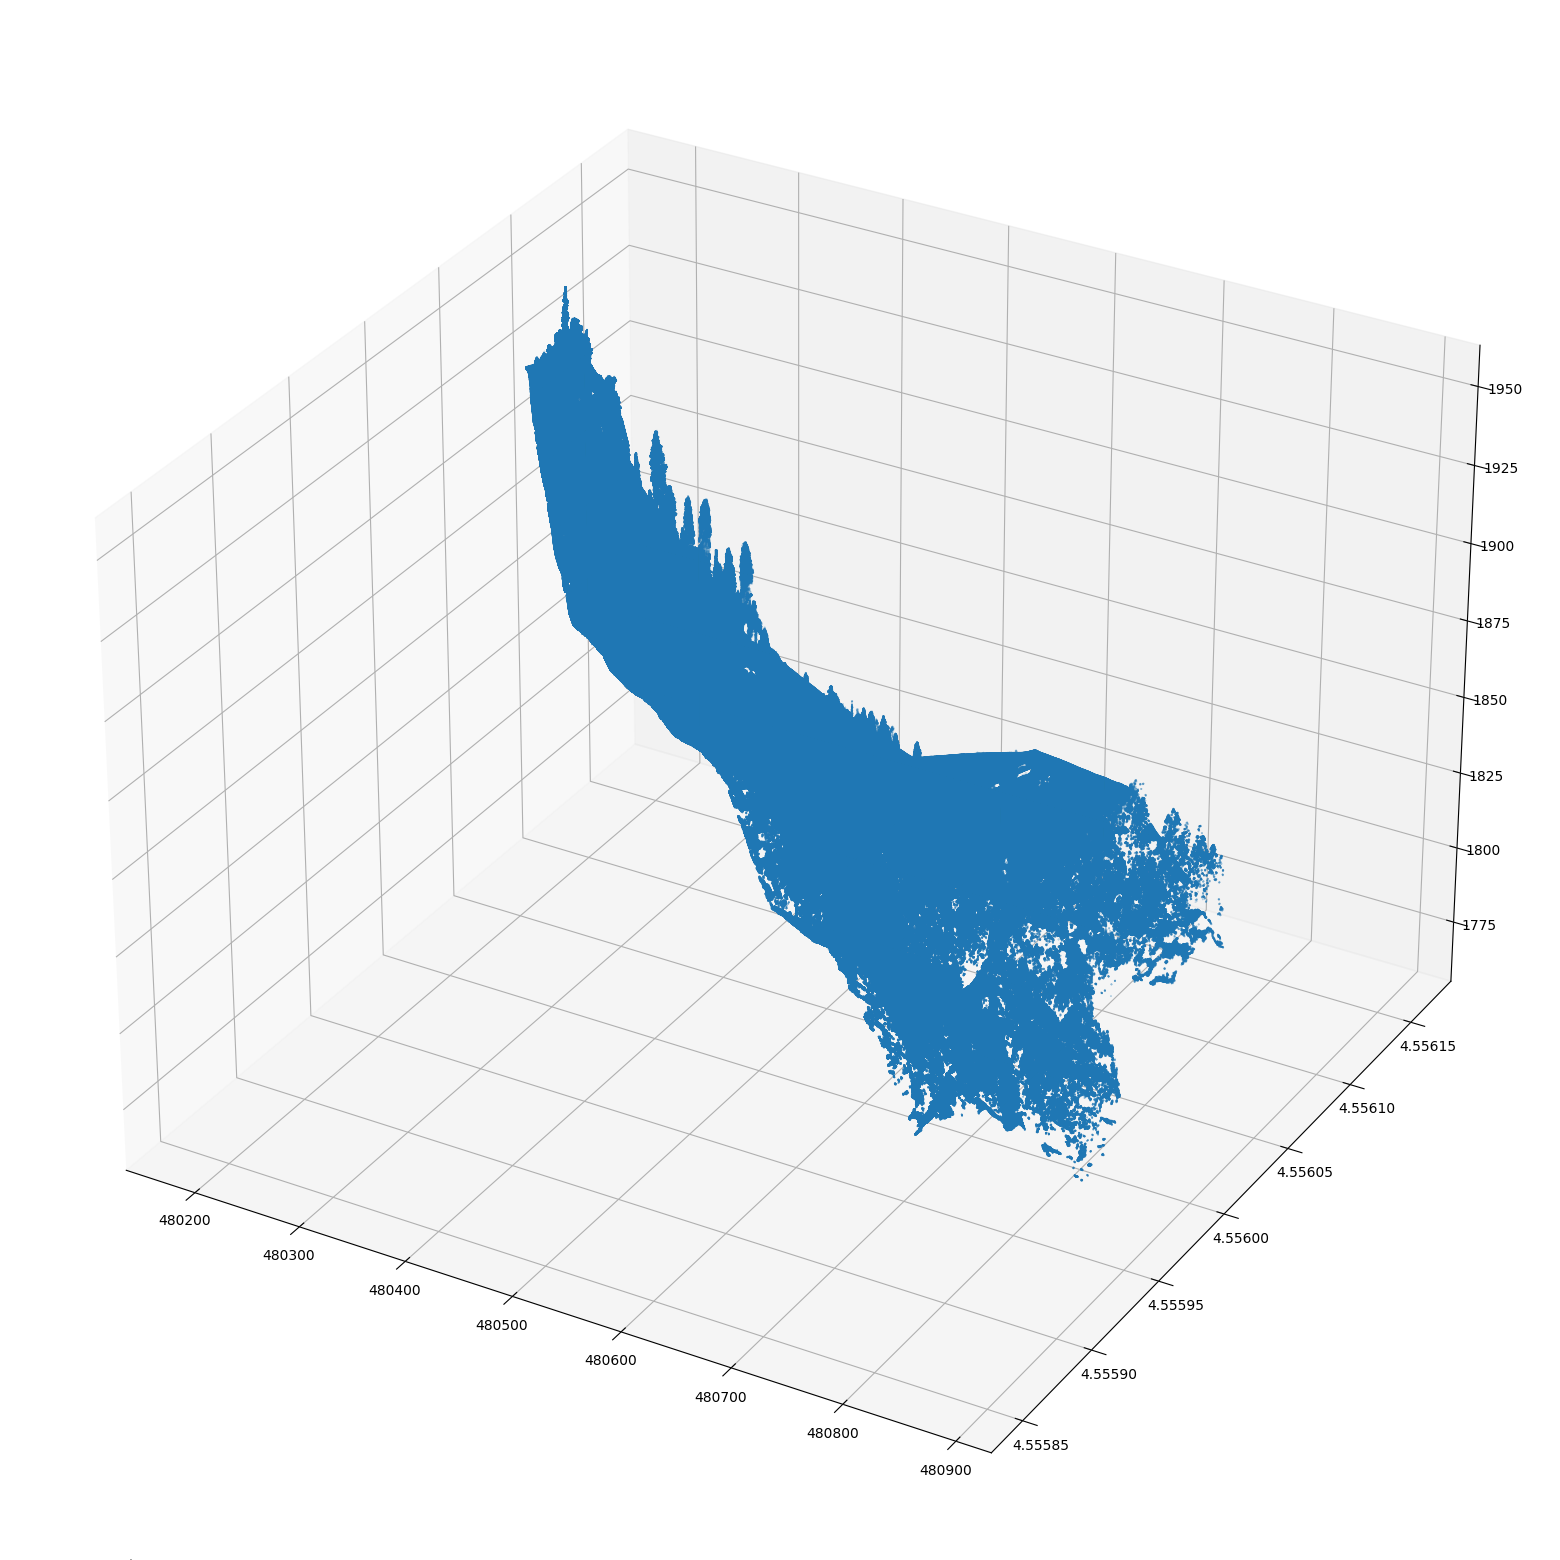

In [ ]:
fig = plt.figure(figsize=(20,20))
ax= fig.add_subplot(111, projection='3d')

ax.scatter(df.iloc[:,0], df.iloc[:,1],df.iloc[:,2], s=.1)

plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler

In [ ]:
labels=df['CLASS']
features=df[['X','Y','Z','INTENSITY','RED','GREEN','BLUE']]

In [ ]:
from sklearn.preprocessing import MinMaxScaler
features_scaled = MinMaxScaler().fit_transform(features)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(features_scaled, labels,
test_size=0.4)

In [ ]:
X_test, X_valid, y_test, y_valid = train_test_split(X_test, y_test, test_size=0.5)

In [ ]:
# Veri seti boyutlarını kontrol etme
print(f"Eğitim Seti: {X_train.shape[0]} örnek")
print(f"Test Seti: {X_test.shape[0]} örnek")
print(f"Doğrulama Seti: {X_valid.shape[0]} örnek")

Eğitim Seti: 25722064 örnek
Test Seti: 8574021 örnek
Doğrulama Seti: 8574022 örnek


In [ ]:
dtc_classifier = DecisionTreeClassifier()

In [ ]:
dtc_classifier.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
dtc_predictions = dtc_classifier.predict(X_test)

/usr/local/lib/python3.10/dist-packages/matplotlib/collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


Text(0.5, 1.0, 'Farklar')

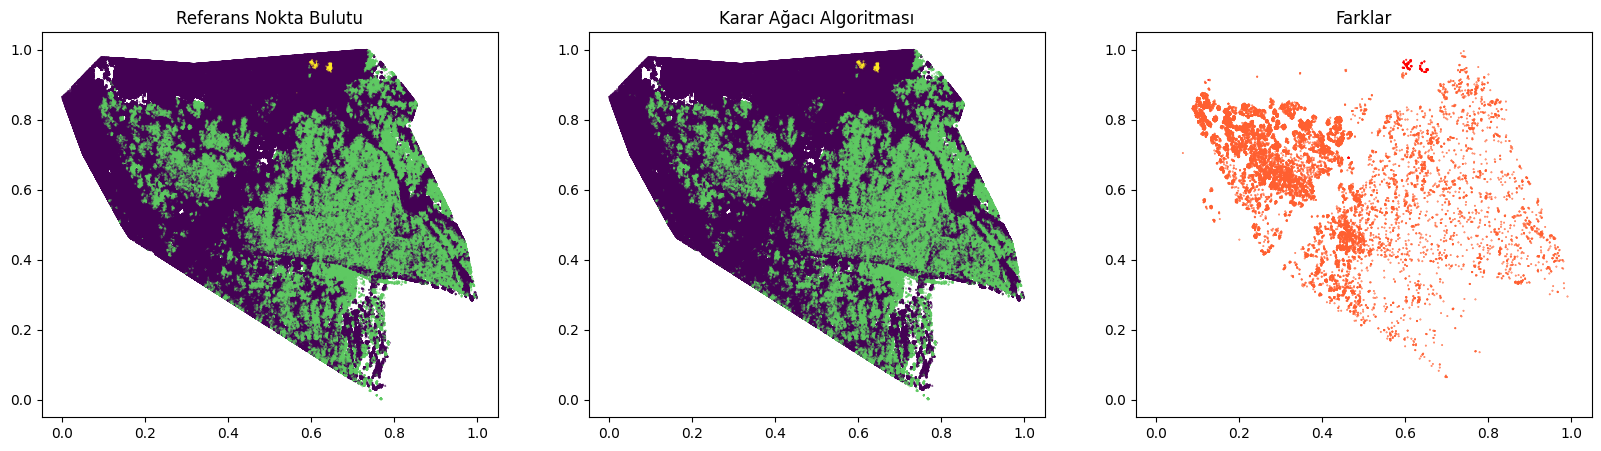

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(20,5))
axs[0].scatter(X_test[:, 0], X_test[:, 1], c =y_test, s=0.05)
axs[0].set_title('Referans Nokta Bulutu')
axs[1].scatter(X_test[:, 0], X_test[:, 1], c = dtc_predictions, s=0.05)
axs[1].set_title('Karar Ağacı Algoritması')
axs[2].scatter(X_test[:, 0], X_test[:, 1], c = y_test-dtc_predictions, cmap =
plt.cm.rainbow, s=0.05*(y_test-dtc_predictions))
axs[2].set_title('Farklar')


In [ ]:
print(classification_report(y_test, dtc_predictions))

              precision    recall  f1-score   support

         2.0       0.99      1.00      0.99   4527404
         5.0       0.99      0.99      0.99   4045048
         6.0       0.92      0.92      0.92      1569

    accuracy                           0.99   8574021
   macro avg       0.97      0.97      0.97   8574021
weighted avg       0.99      0.99      0.99   8574021



In [ ]:
print(f"Doğruluk Skoru: {accuracy_score(y_test, dtc_predictions):.2f}")

Doğruluk Skoru: 0.99


In [ ]:
class_names = [str(name) for name in labels.unique()]
print(classification_report(y_test, dtc_predictions, target_names=class_names, digits=4))


              precision    recall  f1-score   support

         2.0     0.9946    0.9951    0.9948   4527404
         6.0     0.9945    0.9939    0.9942   4045048
         5.0     0.9233    0.9210    0.9221      1569

    accuracy                         0.9945   8574021
   macro avg     0.9708    0.9700    0.9704   8574021
weighted avg     0.9945    0.9945    0.9945   8574021



In [ ]:
print(confusion_matrix(y_test, dtc_predictions))

[[4505135   22153     116]
 [  24528 4020516       4]
 [    123       1    1445]]


In [ ]:
dtc_classifier.score(X_test, y_test)

0.9945270719537542

In [ ]:
# Doğrulama seti ile tahmin
y_valid_pred = dtc_classifier.predict(X_valid)

# Performans değerlendirme
print("Doğrulama Seti Performansı:")
print(classification_report(y_valid, y_valid_pred))

Doğrulama Seti Performansı:
              precision    recall  f1-score   support

         2.0       0.99      1.00      1.00   4526671
         5.0       0.99      0.99      0.99   4045783
         6.0       0.92      0.91      0.92      1568

    accuracy                           0.99   8574022
   macro avg       0.97      0.97      0.97   8574022
weighted avg       0.99      0.99      0.99   8574022



In [ ]:
print(confusion_matrix(y_valid, y_valid_pred))

[[4505421   21128     122]
 [  23329 4022450       4]
 [    134       5    1429]]


In [ ]:
class_names = [str(name) for name in labels.unique()]
print(classification_report(y_valid, y_valid_pred, target_names=class_names, digits=4))

              precision    recall  f1-score   support

         2.0     0.9945    0.9952    0.9949   4527492
         6.0     0.9946    0.9939    0.9943   4044970
         5.0     0.9304    0.9173    0.9238      1560

    accuracy                         0.9946   8574022
   macro avg     0.9732    0.9688    0.9710   8574022
weighted avg     0.9946    0.9946    0.9946   8574022



In [ ]:
from sklearn.metrics import accuracy_score

# Eğitim setindeki doğruluk
train_accuracy = accuracy_score(y_train, dtc_classifier.predict(X_train))

# Test setindeki doğruluk
test_accuracy = accuracy_score(y_test, dtc_classifier.predict(X_test))

print(f"Eğitim Doğruluğu: {train_accuracy:.2f}")
print(f"Test Doğruluğu: {test_accuracy:.2f}")

if train_accuracy - test_accuracy > 0.1:  # %10'dan fazla fark
    print("Modeliniz aşırı öğrenme yapmış olabilir.")
else:
    print("Modeliniz iyi genelleme yapıyor.")

Eğitim Doğruluğu: 1.00
Test Doğruluğu: 0.99
Modeliniz iyi genelleme yapıyor.


In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

In [ ]:
def plot_roc(y_test, rf_predictions):
  # Binarize the labels for multiclass ROC
  y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
  n_classes = y_test_bin.shape[1]

  # Compute ROC curve and ROC area for each class
  fpr = dict()
  tpr = dict()
  roc_auc = dict()
  for i in range(n_classes):
      fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], rf_predictions) # Removed second index from rf_predictions
      roc_auc[i] = auc(fpr[i], tpr[i])

  # Plot ROC curves for each class
  for i in range(n_classes):
      plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'
                                   ''.format(i, roc_auc[i]))

  plt.plot([0, 1], [0, 1], 'k--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Receiver Operating Characteristic for Multi-Class')
  plt.legend(loc="lower right")
  plt.show()


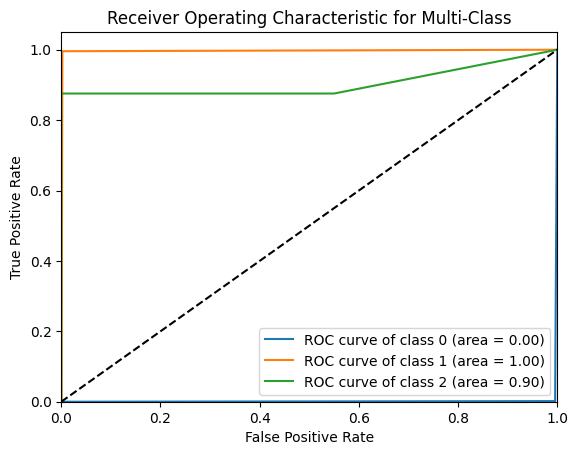

In [ ]:
plot_roc(y_test, rf_predictions)

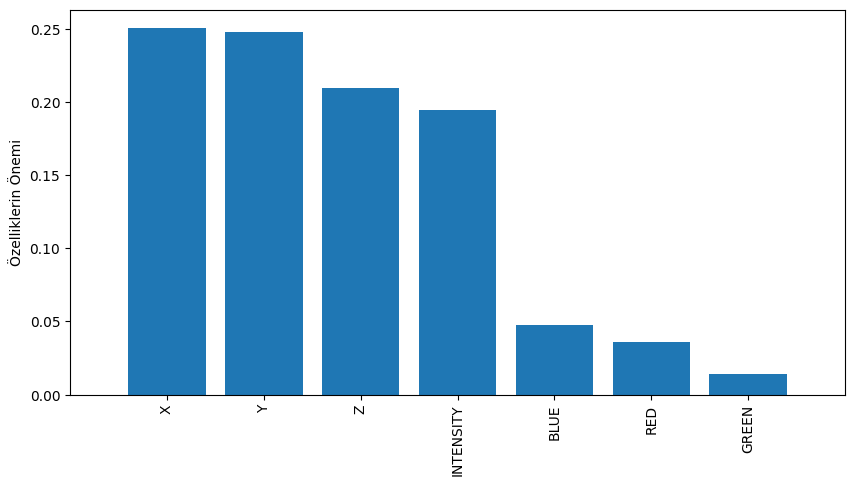

In [ ]:
importances = dtc_classifier.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,5))
plt.ylabel("Özelliklerin Önemi")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")

feat_labels = features.columns[indices]
plt.xticks(range(X_train.shape[1]),feat_labels[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()

